In [1]:
from sampo.scheduler.genetic import GeneticScheduler
from sampo.schemas.graph import WorkGraph
from LLMHeuristicScheduler.base import LLMHeuristicScheduler
from sampo_api import contractor


from sampo.base import SAMPO

import seaborn as sns
import logging
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import os

Can not find native module; switching to default


# Genetic Algrotihm basic SAMPO  vs Genetic Algorithm with LLMs generated init population

Цель исследования:    
    - Проверить сходимость за сколько был достигнут GAP = 0,   
    Гипотеза: Iter_LLM <  Iter_GA    
    - Оптимальность  
    Гипотеза: makespan_LLM < makespan_GA


In [2]:
class StatsCollector:
    def __init__(self,):
        self.items = []

    def add(self, fitness):
        self.items.append(fitness)
    def clear(self):
        self.items = []
class StatsHandler(logging.Handler):
    pattern = re.compile(
        r"-- Generation (?P<generation>\d+), population=(?P<population>\d+), best fitness=\((?P<fitness>\d+)\.0,\) --"
    )
    def __init__(self, collector):
        super().__init__()
        self.collector = collector  # сюда кладём внешний объект
    def emit(self, record):
        msg = self.format(record)
        m = self.pattern.search(msg)
        if not m:
            return
        #generation = int(m.group("generation"))
        fitness = float(m.group("fitness"))
        self.collector.add(fitness)

In [6]:
def init_experiment(GA_params, model_names, imprortance):
    solvers_dict = {}
    solvers_dict['genetic'] = GeneticScheduler(**GA_params)
    for model_name in model_names:
        model = LLMHeuristicScheduler(model_name, **GA_params, 
                                      imprortance=imprortance)
        solvers_dict[model_name] = model
    return solvers_dict

def experiment_df(experiment_logs):
    res = []
    for name, runs in experiment_logs.items():
        for i, run in enumerate(runs, start=1):
            df = pd.DataFrame({'Makespan' : run, 'Time' : range(1, len(run) + 1), 'run' : i, 'Algorithm' : name})
            res.append(df)
    df_res = pd.concat(res)
    return df_res

def run_experiment(solvers_dict, wg, contractors, N_runs):
    sc = StatsCollector()
    stats_handler = StatsHandler(sc)
    SAMPO.logger.addHandler(stats_handler)
    experiment_logs = defaultdict(list)
    for i in range(N_runs):
        for solver, model in solvers_dict.items():
            model.schedule(wg, contractors)
            experiment_logs[solver].append(sc.items)
            sc.clear()
    return experiment_logs



GA  = {
    'number_of_generation' : 3,
    'size_of_population' : 60,
    'mutate_order' : 0.05,
    'mutate_resources': 0.05,
    'mutate_zones': 0.05} 


#wg , contractors  = WorkGraph.loadf('wgs/100', '100_0'), contractor(N=5)


wg , contractors  = WorkGraph.loadf('wgs/small_synth', 'wg_5'), contractor(N=5)
solvers_dict = init_experiment(GA, ['claude_haiku_4.5', ], 9)
experiment_logs = run_experiment(solvers_dict, wg, contractors, 3)


[SAMPO] [INFO] Toolbox initialization & first population took 8.974075317382812 ms


Genetic optimizing took 8.775949478149414 ms


[SAMPO] [INFO] First population evaluation took 366.7631149291992 ms
[SAMPO] [INFO] -- Generation 1, population=60, best fitness=(72.0,) --
[SAMPO] [INFO] -- Generation 2, population=60, best fitness=(72.0,) --
[SAMPO] [INFO] -- Generation 3, population=60, best fitness=(72.0,) --
[SAMPO] [INFO] Final fitness: (64.0,)
[SAMPO] [INFO] Generations processing took 1277.0881652832031 ms
[SAMPO] [INFO] Full genetic processing took 2643.286943435669 ms
[SAMPO] [INFO] Evaluation time: 1436.9502067565918
[SAMPO] [INFO] Toolbox initialization & first population took 12.361288070678711 ms


+1 solve Latest Start Time Priority Rule (LST) 127
+1 solve Shortest Processing Time Priority Rule (SPT) 32
+1 solve Greatest Resource Demand Priority Rule (GRD) 74
+1 solve Most Successors Priority Rule (MS2) 104
+1 solve Minimum Slack Priority Rule (MS1) 117
+1 solve Latest Finish Time Priority Rule (LFT) 92
Genetic optimizing took 12.138128280639648 ms


[SAMPO] [INFO] First population evaluation took 348.16527366638184 ms
[SAMPO] [INFO] -- Generation 1, population=60, best fitness=(53.0,) --
[SAMPO] [INFO] -- Generation 2, population=60, best fitness=(53.0,) --
[SAMPO] [INFO] -- Generation 3, population=60, best fitness=(50.0,) --
[SAMPO] [INFO] Final fitness: (50.0,)
[SAMPO] [INFO] Generations processing took 1205.5871486663818 ms
[SAMPO] [INFO] Full genetic processing took 2410.386085510254 ms
[SAMPO] [INFO] Evaluation time: 1436.9544982910156
[SAMPO] [INFO] Toolbox initialization & first population took 8.569955825805664 ms


...

[SAMPO] [INFO] First population evaluation took 365.6449317932129 ms
[SAMPO] [INFO] -- Generation 1, population=60, best fitness=(59.0,) --
[SAMPO] [INFO] -- Generation 2, population=60, best fitness=(59.0,) --
[SAMPO] [INFO] -- Generation 3, population=60, best fitness=(59.0,) --
[SAMPO] [INFO] Final fitness: (59.0,)
[SAMPO] [INFO] Generations processing took 1241.0540580749512 ms
[SAMPO] [INFO] Full genetic processing took 2475.055932998657 ms
[SAMPO] [INFO] Evaluation time: 1483.567714691162
[SAMPO] [INFO] Toolbox initialization & first population took 8.70513916015625 ms


Genetic optimizing took 8.24427604675293 ms


[SAMPO] [INFO] First population evaluation took 352.431058883667 ms
[SAMPO] [INFO] -- Generation 1, population=60, best fitness=(72.0,) --
[SAMPO] [INFO] -- Generation 2, population=60, best fitness=(49.0,) --
[SAMPO] [INFO] -- Generation 3, population=60, best fitness=(49.0,) --
[SAMPO] [INFO] Final fitness: (49.0,)
[SAMPO] [INFO] Generations processing took 1300.6830215454102 ms
[SAMPO] [INFO] Full genetic processing took 2600.5990505218506 ms
[SAMPO] [INFO] Evaluation time: 1411.9491577148438
[SAMPO] [INFO] Toolbox initialization & first population took 12.763023376464844 ms


+1 solve Latest Start Time Priority Rule (LST) 127
+1 solve Shortest Processing Time Priority Rule (SPT) 32
+1 solve Greatest Resource Demand Priority Rule (GRD) 74
+1 solve Most Successors Priority Rule (MS2) 104
+1 solve Minimum Slack Priority Rule (MS1) 117
+1 solve Latest Finish Time Priority Rule (LFT) 92
Genetic optimizing took 12.495040893554688 ms


[SAMPO] [INFO] First population evaluation took 365.53215980529785 ms
[SAMPO] [INFO] -- Generation 1, population=60, best fitness=(67.0,) --
[SAMPO] [INFO] -- Generation 2, population=60, best fitness=(67.0,) --
[SAMPO] [INFO] -- Generation 3, population=60, best fitness=(50.0,) --
[SAMPO] [INFO] Final fitness: (50.0,)
[SAMPO] [INFO] Generations processing took 1239.1531467437744 ms
[SAMPO] [INFO] Full genetic processing took 2464.9598598480225 ms
[SAMPO] [INFO] Evaluation time: 1484.858751296997


(0.0, 75.0)

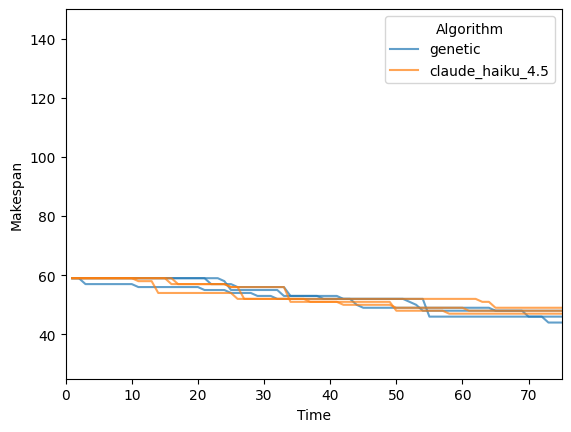

In [29]:
sns.lineplot(experiment_df(experiment_logs),
              x='Time', y='Makespan', hue='Algorithm', 
              units='run', estimator=None, alpha=0.7)

plt.ylim((25, 150))
plt.xlim((0, 75))

# Проверка гипотезы о весах в ГА

In [ ]:
def tail_share(weights, tail_indices, p_init=1/3):
    W = sum(weights)
    W_tail = sum(weights[tail_indices:])
    return p_init * W_tail / W  # доля в общей популяции


print('Deepseek Chat')
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 9, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [2] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [1] * 9, tail_indices=7) / 0.33 )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [6] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [5] * 9, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [12] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [10] * 9, tail_indices=7) / 0.33)


print('Reasoner')
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 5, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [2] * 5, tail_indices=7) / 0.33 )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [6] * 5, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [12] * 5, tail_indices=7) )


In [ ]:
from sampo.schemas.graph import WorkGraph

def init_experiment(GA_params, model_names, imprt):
    solvers_dict = {}
    solvers_dict['genetic'] = GeneticScheduler(**GA_params)
    for model_name in model_names:
        model = LLMHeuristicScheduler(model_name, **GA_params, imprt=imprt)
        solvers_dict[model_name] = model
    return solvers_dict

def experiment_df(experiment_logs):
    res = []
    for name, runs in experiment_logs.items():
        if name == 'weight_param':
            continue
        for i, run in enumerate(runs, start=1):
            df = pd.DataFrame({'Makespan' : run, 'Time' : range(1, len(run) + 1), 'run' : i, 'Algorithm' : name})
            res.append(df)
    df_res = pd.concat(res)
    df_res['weight_param'] = experiment_logs['weight_param'] 
    return df_res

def run_experiments(GA, wg, weights, contractors, N_runs):
    sc = StatsCollector()
    stats_handler = StatsHandler(sc)
    SAMPO.logger.addHandler(stats_handler)
    res_dfs = []
    for weight in weights:
        experiment_logs = defaultdict(list)
        solvers_dict = init_experiment(GA, ['deepseek_chat', 'deepseek_reasoner'], imprt=weight)
        for _ in range(N_runs):
            for solver, model in solvers_dict.items():
                if weight >= weights[0] and solver == 'genetic':
                # Skip other experiments
                    continue
                model.schedule(wg, contractors)
                experiment_logs[solver].append(sc.items)
                experiment_logs['weight_param'] = weight
                sc.clear()
            res_dfs.append(experiment_df(experiment_logs))
    
    return res_dfs


GA  = {
    'number_of_generation' : 150,
    'size_of_population' : 50,
    'mutate_order' : 0.05,
    'mutate_resources': 0.05,
    'mutate_zones': 0.05} 


weights = (8, 9, 10)


wg , contractors  = WorkGraph.loadf('wgs/small_synth', 'wg_9'), contractor(N=5)
dfs = run_experiments(GA, wg, contractors, 5)


In [ ]:
data = pd.concat(dfs)
data.to_csv('weight_experiment2_df.csv', index=False)

#data.to_csv('weight_experiment2_weights_df.csv', index=False)


# Meta

# GA  = {
#     'number_of_generation' : 150,
#     'size_of_population' : 50,
#     'mutate_order' : 0.05,
#     'mutate_resources': 0.05,
#     'mutate_zones': 0.05} 


#df_experiment.to_csv('weight_experiment_df.csv', index=False)


# Meta

# GA  = {
#     'number_of_generation' : 100,
#     'size_of_population' : 50,
#     'mutate_order' : 0.05,
#     'mutate_resources': 0.05,
#     'mutate_zones': 0.05} 



In [ ]:
# from sampo.schemas.graph import WorkGraph
# import os
# from sampo_api import contractor

# maxx, minn = -float('inf'), float('inf')
# for f in os.listdir('wgs/small_synth'):
#         wg , contractors = WorkGraph.loadf('wgs/small_synth', f[:-5]), contractor(N=5)
#         N = len(wg.nodes) 
#         print( f, N)
#         maxx = max(maxx, N)
#         minn = min(minn, N)

# print(maxx, minn)

# Experiment with structure in GA
    - `Classic` GA vs `High Weight` in init_popul vs `Only model generated` init_popul

In [23]:
from LLMHeuristicScheduler.base import LLMHeuristicScheduler
from sampo_api import contractor
from sampo.schemas.graph import WorkGraph

wg , contractors  = WorkGraph.loadf('wgs/100', '100_0'), contractor(N=10)


def experiment_df(experiment_logs):
    res = []
    for name, runs in experiment_logs.items():
        for i, run in enumerate(runs, start=1):
            df = pd.DataFrame({'Makespan' : run, 'Time' : range(1, len(run) + 1), 
                               'run' : i, 'Algorithm' : name})
            res.append(df)
    df_res = pd.concat(res)
    return df_res



def init_experiment(GA_params, 
                    model_name, 
                    structures = (None, 'onlyGeneratedHeurisitcs'), 
                    imprt = 10):
    solvers_dict = {}
    solvers_dict['genetic'] = GeneticScheduler(**GA_params)
    for structure in structures:
        model = LLMHeuristicScheduler(model_name, 
                                      **GA_params, 
                                      type_init_pop_structure=structure, 
                                      imprortance=imprt)
        if structure is None:
            structure = 'highWeights'
        solvers_dict[model_name + '_' + structure] = model
    return solvers_dict

def run_experiments(GA, wg, contractors, model_name, N_runs):
    sc = StatsCollector()
    stats_handler = StatsHandler(sc)
    SAMPO.logger.addHandler(stats_handler)
    res_dfs = []
    experiment_logs = defaultdict(list)
    solvers_dict = init_experiment(GA, model_name)
    for _ in range(N_runs):
        for solver, model in solvers_dict.items():
            model.schedule(wg, contractors)
            experiment_logs[solver].append(sc.items)
            sc.clear()
            res_dfs.append(experiment_df(experiment_logs))
    return res_dfs


GA  = {
    'number_of_generation' : 100,
    'size_of_population' : 50,
    'mutate_order' : 0.05,
    'mutate_resources': 0.05,
    'mutate_zones': 0.05} 

dfs = run_experiments(GA, wg, contractors, 'deepseek_reasoner', 4)

[SAMPO] [INFO] Toolbox initialization & first population took 22.528886795043945 ms


Genetic optimizing took 20.195960998535156 ms


[SAMPO] [INFO] First population evaluation took 749.7918605804443 ms
[SAMPO] [INFO] -- Generation 1, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 2, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 3, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 4, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 5, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 6, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 7, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 8, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 9, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 10, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 11, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 12, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 13, population=50, best fitness=(61.0,) --
[SAM

Genetic optimizing took 24.703025817871094 ms


[SAMPO] [INFO] First population evaluation took 843.1260585784912 ms
[SAMPO] [INFO] -- Generation 1, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 2, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 3, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 4, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 5, population=50, best fitness=(56.0,) --
[SAMPO] [INFO] -- Generation 6, population=50, best fitness=(56.0,) --
[SAMPO] [INFO] -- Generation 7, population=50, best fitness=(56.0,) --
[SAMPO] [INFO] -- Generation 8, population=50, best fitness=(56.0,) --
[SAMPO] [INFO] -- Generation 9, population=50, best fitness=(56.0,) --
[SAMPO] [INFO] -- Generation 10, population=50, best fitness=(56.0,) --
[SAMPO] [INFO] -- Generation 11, population=50, best fitness=(56.0,) --
[SAMPO] [INFO] -- Generation 12, population=50, best fitness=(56.0,) --
[SAMPO] [INFO] -- Generation 13, population=50, best fitness=(56.0,) --
[SAM

...

[SAMPO] [INFO] First population evaluation took 847.8250503540039 ms
[SAMPO] [INFO] -- Generation 1, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 2, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 3, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 4, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 5, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 6, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 7, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 8, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 9, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 10, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 11, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 12, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 13, population=50, best fitness=(61.0,) --
[SAM

Genetic optimizing took 23.710966110229492 ms


[SAMPO] [INFO] First population evaluation took 741.696834564209 ms
[SAMPO] [INFO] -- Generation 1, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 2, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 3, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 4, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 5, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 6, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 7, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 8, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 9, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 10, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 11, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 12, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 13, population=50, best fitness=(61.0,) --
[SAMP

5 50 [10, 10, 10, 10, 10]
Genetic optimizing took 25.151968002319336 ms


[SAMPO] [INFO] Toolbox initialization & first population took 26.859045028686523 ms
[SAMPO] [INFO] First population evaluation took 867.652177810669 ms
[SAMPO] [INFO] -- Generation 1, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 2, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 3, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 4, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 5, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 6, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 7, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 8, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 9, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 10, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 11, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 12, population=50, best fitness=(61.

In [24]:
pd.concat(dfs).groupby('Algorithm').Makespan.min()

Algorithm
deepseek_reasoner_highWeights                37.0
deepseek_reasoner_onlyGeneratedHeurisitcs    48.0
genetic                                      38.0
Name: Makespan, dtype: float64

In [25]:
pd.concat(dfs).to_csv('structure_experiment_DRChat.csv', index=False)

In [6]:
str(None)

'None'

In [ ]:
# from sampo.schemas.graph import WorkGraph
# WorkGraph.loadf('wgs/100', '100_0')

WorkGraph(start=9c9ba1dc-75eb-4a11-9d5c-de8f88aa7590, finish=b7c87a71-1287-4a45-ade2-a4c6a5c0457f, nodes=[9c9ba1dc-75eb-4a11-9d5c-de8f88aa7590, ec229d76-9243-cc92-86ec-504339915a99, 7757e74f-0abb-7598-00fa-058a3e61c27b, 9f6438fc-db76-756c-4e93-4e91a569fcdf, 4e8799b4-5962-697a-0ae1-cf88ecbc56e3, 5ab4ba3b-bc0e-eaa7-9f93-7804475188b3, 829722d1-81a7-6c4b-248b-37506097fda1, 42008312-2fad-578d-24b4-7aaf99a4fa92, 08fa42cc-af4c-8471-04f4-5921696830d1, 6dba69ad-9b07-d3dc-a536-4c095b0ea748, 26b32036-1277-f1c3-9ccb-1134f245bfe5, 32e435ce-8076-6e9d-9a4f-6b7df4aee07f, a1c5cd04-6c61-b7cb-d771-5297453371d7, 1faa2c6f-f3c1-5656-25df-306af2c0adf6, ed53268e-8d0b-8169-3bb1-27d41b9ac01b, b81ad10c-c804-66a7-e251-e56fc13858f6, 49c120e9-b9aa-4a8f-6892-b0b5a2566a7f, 7648944a-6bbf-94be-bc08-8e03e0db082f, 04309122-58aa-80b2-b67f-9206b1887684, 2e371fb0-60e7-2cf5-107a-59d96c49c7b2, 21355378-4b00-4a7d-b2e4-857e7b755860, f6613c83-8595-724e-5ca6-cefa386e32ae, b51a0845-a6a7-b991-a9e9-bd2e51485db6, 66891097-d5aa-52f2-c

In [ ]:
GA  = {
    'number_of_generation' : 150,
    'size_of_population' : 50,
    'mutate_order' : 0.05,
    'mutate_resources': 0.05,
    'mutate_zones': 0.05} 
scheduler = LLMHeuristicScheduler('deepseek_reasoner', 
                                  **GA,  
                                 type_init_pop_structure='onlyGeneratedHeurisitcs')
scheduler.schedule(wg, contractors)


[SAMPO] [INFO] Toolbox initialization & first population took 23.43606948852539 ms


5 50 [10, 10, 10, 10, 10]
Genetic optimizing took 23.360013961791992 ms


[SAMPO] [INFO] First population evaluation took 758.3761215209961 ms
[SAMPO] [INFO] -- Generation 1, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 2, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 3, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 4, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 5, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 6, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 7, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 8, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 9, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 10, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 11, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 12, population=50, best fitness=(61.0,) --
[SAMPO] [INFO] -- Generation 13, population=50, best fitness=(61.0,) --
[SAM